<a href="https://colab.research.google.com/github/hiralgundecha/machinelearning/blob/main/Lab03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub
path = kagglehub.dataset_download("nelgiriyewithana/countries-of-the-world-2023")

100%|██████████| 23.5k/23.5k [00:00<00:00, 15.1MB/s]

Extracting files...


In [2]:
import kagglehub
path = kagglehub.dataset_download("rohanrao/air-quality-data-in-india")

Using Colab cache for faster access to the 'air-quality-data-in-india' dataset.


In [3]:
import kagglehub
import pandas as pd
import os

path = kagglehub.dataset_download("rohanrao/air-quality-data-in-india")

# Load CSV files
files = os.listdir(path)
print(files)

df = pd.read_csv(os.path.join(path, files[0]))
df.head()

Using Colab cache for faster access to the 'air-quality-data-in-india' dataset.
['stations.csv', 'station_hour.csv', 'city_day.csv', 'city_hour.csv', 'station_day.csv']


,StationId,StationName,City,State,Status
0,AP001,"Secretariat, Amaravati - APPCB",Amaravati,Andhra Pradesh,Active
1,AP002,"Anand Kala Kshetram, Rajamahendravaram - APPCB",Rajamahendravaram,Andhra Pradesh,NaN
2,AP003,"Tirumala, Tirupati - APPCB",Tirupati,Andhra Pradesh,NaN
3,AP004,"PWD Grounds, Vijayawada - APPCB",Vijayawada,Andhra Pradesh,NaN
4,AP005,"GVM Corporation, Visakhapatnam - APPCB",Visakhapatnam,Andhra Pradesh,Active


In [4]:
df.info()
df.describe()
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 230 entries, 0 to 229
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   StationId    230 non-null    object
 1   StationName  230 non-null    object
 2   City         230 non-null    object
 3   State        230 non-null    object
 4   Status       133 non-null    object
dtypes: object(5)
memory usage: 9.1+ KB


,0
StationId,0
StationName,0
City,0
State,0
Status,97


In [5]:
df['Date'] = pd.to_datetime(df['Date'])
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month


KeyError: 'Date'

In [6]:
df.columns


Index(['StationId', 'StationName', 'City', 'State', 'Status'], dtype='object')

In [7]:
import os
os.listdir(path)


['stations.csv',
 'station_hour.csv',
 'city_day.csv',
 'city_hour.csv',
 'station_day.csv']

In [8]:
df = pd.read_csv(os.path.join(path, "city_day.csv"))
df.head()


,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


In [11]:
df.head()


,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket,Year,Month
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN,2015,1
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN,2015,1
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN,2015,1
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN,2015,1
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN,2015,1


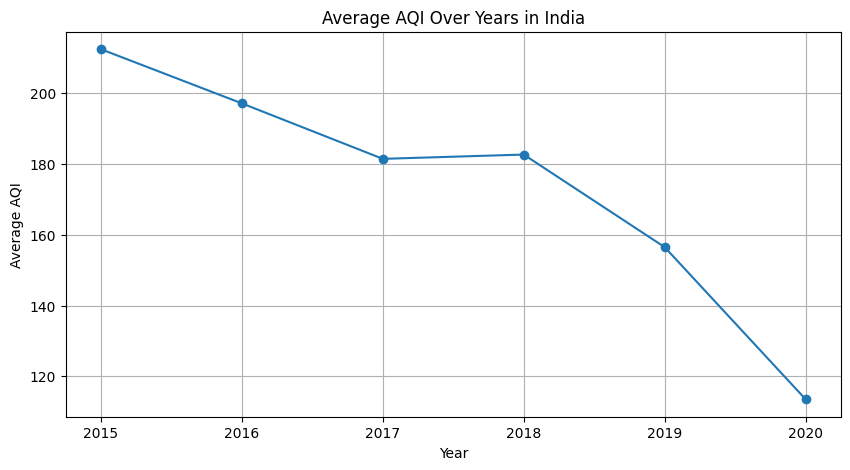

In [12]:
import matplotlib.pyplot as plt

yearly_aqi = df.groupby('Year')['AQI'].mean()

plt.figure(figsize=(10,5))
plt.plot(yearly_aqi.index, yearly_aqi.values, marker='o')
plt.title("Average AQI Over Years in India")
plt.xlabel("Year")
plt.ylabel("Average AQI")
plt.grid(True)
plt.show()


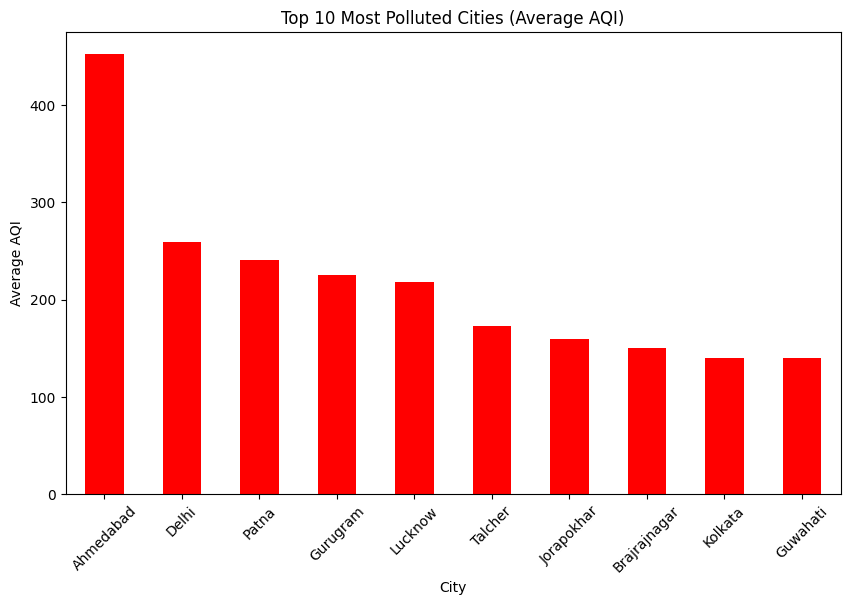

In [13]:
top_cities = df.groupby('City')['AQI'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
top_cities.plot(kind='bar', color='red')
plt.title("Top 10 Most Polluted Cities (Average AQI)")
plt.xlabel("City")
plt.ylabel("Average AQI")
plt.xticks(rotation=45)
plt.show()


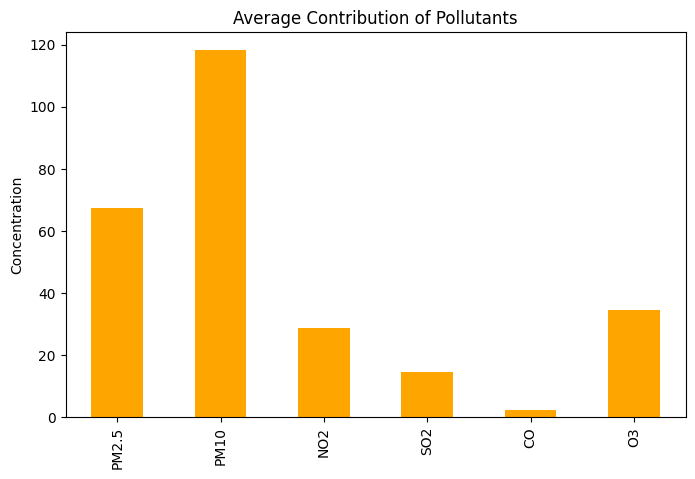

In [14]:
pollutants = ['PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'O3']
pollutant_avg = df[pollutants].mean()

plt.figure(figsize=(8,5))
pollutant_avg.plot(kind='bar', color='orange')
plt.title("Average Contribution of Pollutants")
plt.ylabel("Concentration")
plt.show()


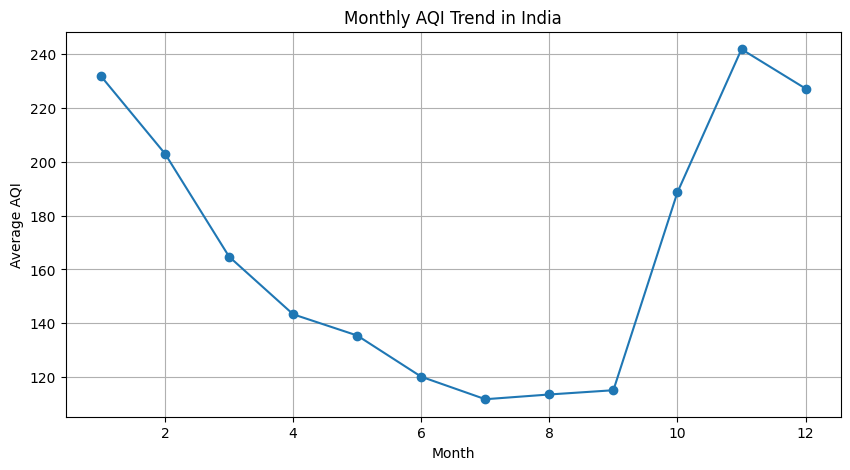

In [15]:
monthly_aqi = df.groupby('Month')['AQI'].mean()

plt.figure(figsize=(10,5))
plt.plot(monthly_aqi.index, monthly_aqi.values, marker='o')
plt.title("Monthly AQI Trend in India")
plt.xlabel("Month")
plt.ylabel("Average AQI")
plt.grid(True)
plt.show()


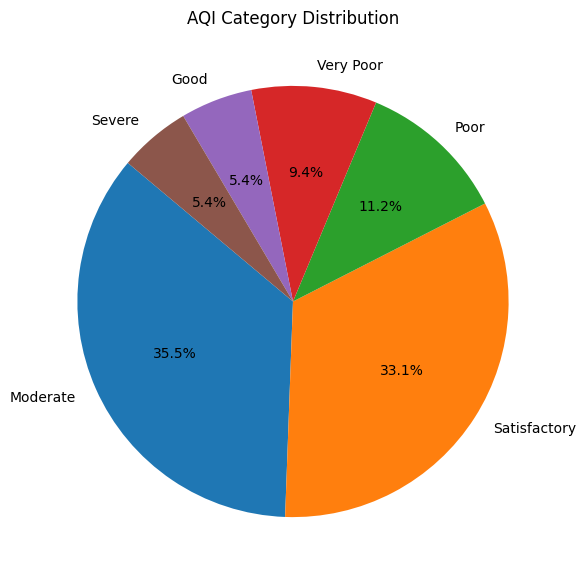

In [16]:
aqi_bucket = df['AQI_Bucket'].value_counts()

plt.figure(figsize=(7,7))
plt.pie(
    aqi_bucket,
    labels=aqi_bucket.index,
    autopct='%1.1f%%',
    startangle=140
)
plt.title("AQI Category Distribution")
plt.show()


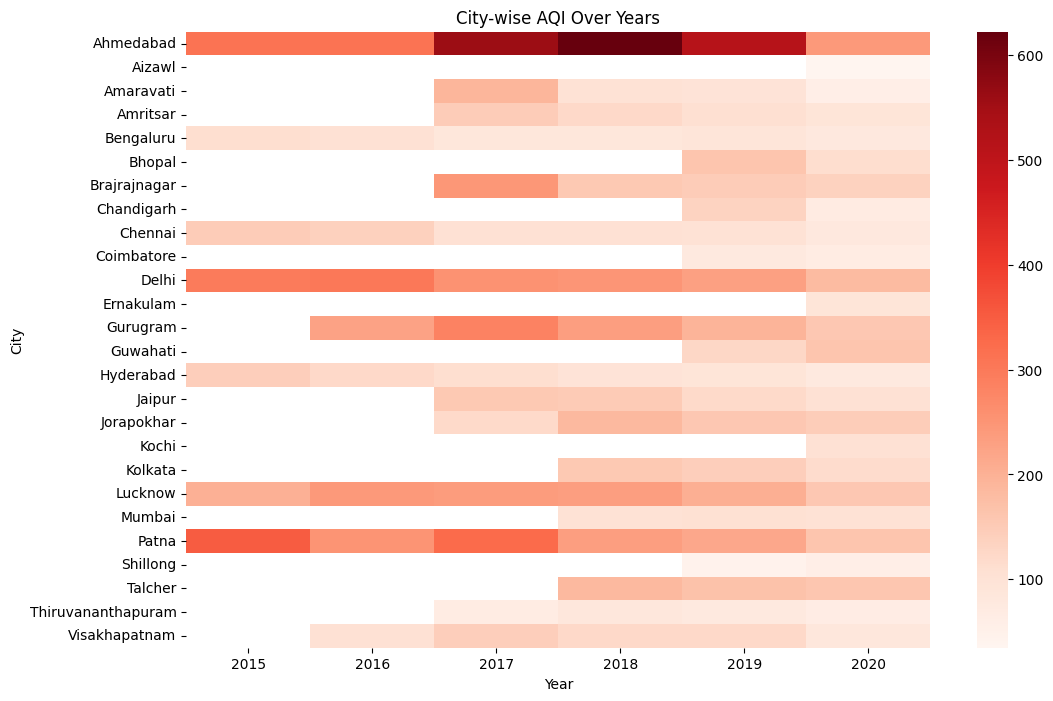

In [17]:
import seaborn as sns

pivot = df.pivot_table(values='AQI', index='City', columns='Year', aggfunc='mean')

plt.figure(figsize=(12,8))
sns.heatmap(pivot, cmap='Reds')
plt.title("City-wise AQI Over Years")
plt.show()
